Метрики качества модели:
  MAE  : 4.260 п.п. (средняя абсолютная ошибка)
  RMSE : 5.701 п.п. (штраф за большие ошибки)
  R²   : 0.967 (доля объяснённой дисперсии)
  Corr : 0.989 (линейная корреляция Пирсона)

Ошибки по диапазонам истинных значений:
  Низкая (<50)    | n=104 | MAE=4.17 | R²=0.780
  Средняя (50-75) | n= 47 | MAE=4.33 | R²=0.199
  Высокая (≥75)   | n= 53 | MAE=5.27 | R²=0.126


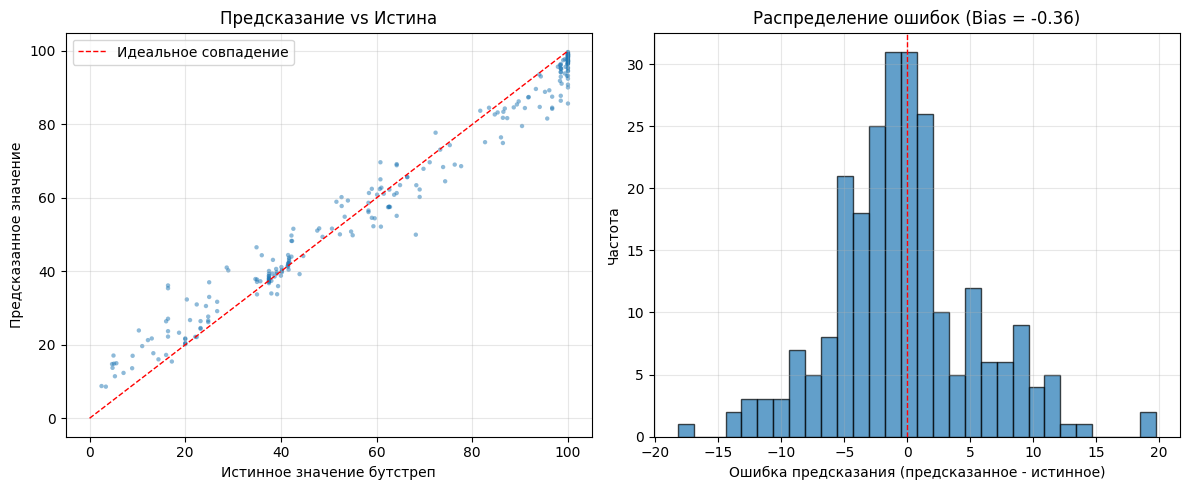


 Проверка границ [0, 100]:
  Предсказаний вне диапазона: 0 из 245 (0.00%)


In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import scipy.stats as stats

df = pd.read_csv("ml4/ml_outputs_v1/test_predictions.csv")
y_true = df["y_true"].values
y_pred = np.clip(df["y_pred"].values, 0, 100)  # Обрезаем в физиологичные границы

mae = mean_absolute_error(y_true, y_pred)
rmse = np.sqrt(mean_squared_error(y_true, y_pred))
r2 = r2_score(y_true, y_pred)
pearson_r, _ = stats.pearsonr(y_true, y_pred)

print(f"Метрики качества модели:")
print(f"  MAE  : {mae:.3f} п.п. (средняя абсолютная ошибка)")
print(f"  RMSE : {rmse:.3f} п.п. (штраф за большие ошибки)")
print(f"  R²   : {r2:.3f} (доля объяснённой дисперсии)")
print(f"  Corr : {pearson_r:.3f} (линейная корреляция Пирсона)")

print(f"\nОшибки по диапазонам истинных значений:")
bins = [0, 50, 75, 100]
labels = ["Низкая (<50)", "Средняя (50-75)", "Высокая (≥75)"]
for b_start, b_end, label in zip(bins[:-1], bins[1:], labels):
    mask = (y_true >= b_start) & (y_true < b_end)
    if mask.sum() > 0:
        subset_mae = mean_absolute_error(y_true[mask], y_pred[mask])
        subset_r2 = r2_score(y_true[mask], y_pred[mask])
        print(f"  {label:15} | n={mask.sum():3d} | MAE={subset_mae:.2f} | R²={subset_r2:.3f}")

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.scatter(y_true, y_pred, alpha=0.5, s=10, edgecolors='none')
plt.plot([0, 100], [0, 100], 'r--', linewidth=1, label='Идеальное совпадение')
plt.xlabel('Истинное значение бутстреп')
plt.ylabel('Предсказанное значение')
plt.title('Предсказание vs Истина')
plt.legend()
plt.grid(alpha=0.3)

plt.subplot(1, 2, 2)
errors = y_pred - y_true
plt.hist(errors, bins=30, edgecolor='black', alpha=0.7)
plt.axvline(x=0, color='red', linestyle='--', linewidth=1)
plt.xlabel('Ошибка предсказания (предсказанное - истинное)')
plt.ylabel('Частота')
plt.title(f'Распределение ошибок (Bias = {errors.mean():.2f})')
plt.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("model_evaluation.png", dpi=150, bbox_inches='tight')
plt.show()

out_of_bounds = np.sum((y_pred < 0) | (y_pred > 100))
print(f"\n Проверка границ [0, 100]:")
print(f"  Предсказаний вне диапазона: {out_of_bounds} из {len(y_pred)} ({100*out_of_bounds/len(y_pred):.2f}%)")

In [ ]:
import matplotlib.pyplot as plt

plt.figure()
plt.scatter(y_true, y_pred)
plt.xlabel("Реальные значения (y_true)")
plt.ylabel("Предсказания (y_pred)")
plt.title("Сравнение реальных и предсказанных значений")

plt.plot([y_true.min(), y_true.max()],
         [y_true.min(), y_true.max()])

plt.show()

In [ ]:
plt.figure()
plt.hist(df["abs_error"], bins=30)
plt.title("Распределение абсолютных ошибок")
plt.xlabel("Абсолютная ошибка")
plt.ylabel("Количество")
plt.show()

In [ ]:
plt.figure()
plt.scatter(y_true, df["abs_error"])
plt.xlabel("Реальное значение")
plt.ylabel("Абсолютная ошибка")
plt.title("Ошибка в зависимости от значения")
plt.show()